# What is Tropical Cyclone Efficiency?

A key principle in treating a tropical cyclone as a thermal heat engine is the thermal maximum $\mathrm{efficiency}$ of the Carnot heat engine itself, which is given in the [BE02](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2001JD000776) potential intensity equation as the term,

$\mathrm{efficiency} = \frac{T_s-T_0}{T_0}$

so that the scaled ratio of the sea surface temperature ($T_s$) and outflow temperature ($T_0$) determines how efficient the storm is at converting potential energy from the sea surface into kinetic energy (in the form of rotational wind speed). Note that this term differs from the typical Carnot efficiency because of the influence of dissipative heating (see the derivation in BE02).

In this notebook we explore the efficiency term by first calculating potential intensity and outflow temperature from ERA5 data, then analytically and empirically the behavior of the efficiency term in an October 2024 monthly-mean example.

### Setup

In [1]:
import sys
from pathlib import Path
_here = Path.cwd().resolve()
repo_root = next((c for c in [_here, *_here.parents] if (c / 'src' / 'tcpyPI').is_dir()), None)
if repo_root is None:
    raise RuntimeError('Could not locate repo root (expected src/tcpyPI).')
sys.path.insert(0, str(repo_root / 'src'))
import numpy as np
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
# load PI calculation module
from tcpyPI import *
# imports utility functions
from tcpyPI.utilities import *

### Load Data

In [2]:
# data location
data_loc = repo_root / "data" / "sample_data.nc"
# load netcdf file
ds = xr.open_dataset(data_loc)

In [3]:
# create the function to output PI calculations
def run_sample_dataset(ds, pdim='p',CKCD=0.9,ascent_flag=0,diss_flag=1,V_reduc=0.8,ptop=50,miss_handle=1):
    """This function calculates PI over an ERA5 dataset using xarray."""
    
    # calculate PI over the whole data set using the xarray universal function
    result = xr.apply_ufunc(
        pi,
        ds['sst'], ds['msl'], ds[pdim], ds['t'], ds['r'],
        kwargs=dict(CKCD=CKCD, ascent_flag=ascent_flag, diss_flag=diss_flag, V_reduc=V_reduc, ptop=ptop, miss_handle=miss_handle),
        input_core_dims=[
            [], [], [pdim, ], [pdim, ], [pdim, ],
        ],
        output_core_dims=[
            [], [], [], [], []
        ],
        vectorize=True
    )

    # store the result in an xarray data structure
    vmax, pmin, ifl, t0, otl = result
    out_ds=xr.Dataset({
        'vmax': vmax, 
        'pmin': pmin,
        'ifl': ifl,
        't0': t0,
        'otl': otl,
        # merge the SST data into the same data structure, to aid efficiency calculations
        'sst': ds.sst+273.15,
        })
    
    # add names and units to the structure
    out_ds.vmax.attrs['standard_name'],out_ds.vmax.attrs['units']='Maximum Potential Intensity','m/s'
    out_ds.pmin.attrs['standard_name'],out_ds.pmin.attrs['units']='Minimum Central Pressure','hPa'
    out_ds.ifl.attrs['standard_name']='pyPI Flag'
    out_ds.t0.attrs['standard_name'],out_ds.t0.attrs['units']='Outflow Temperature','K'
    out_ds.otl.attrs['standard_name'],out_ds.otl.attrs['units']='Outflow Temperature Level','hPa'
    out_ds.sst.attrs['standard_name'],out_ds.otl.attrs['units']='Sea Surface Temperature','K'
    
    # save the pyPI calculation keywords
    out_ds.attrs['pyPI_parameter_CKCD']=CKCD
    out_ds.attrs['pyPI_parameter_ascent_flag']=ascent_flag
    out_ds.attrs['pyPI_parameter_diss_flag']=diss_flag
    out_ds.attrs['pyPI_parameter_V_reduc']=V_reduc
    out_ds.attrs['pyPI_parameter_ptop']=ptop
    out_ds.attrs['pyPI_parameter_miss_handle']=miss_handle

    # return the output from pi.py as an xarray data structure
    return out_ds

In [4]:
# calculate PI over the sample data
pi_ds=run_sample_dataset(ds)

### Efficiency function

In [5]:
Ts_range,T0_range=[297,303],[190,210]
Ts_grid,T0_grid=np.arange(Ts_range[0],Ts_range[-1]+1),np.arange(T0_range[0],T0_range[-1]+1)
Tsv, T0v = np.meshgrid(Ts_grid, T0_grid, sparse=False, indexing='ij')

In [6]:
eta=pi_efficiency(Tsv,T0v)

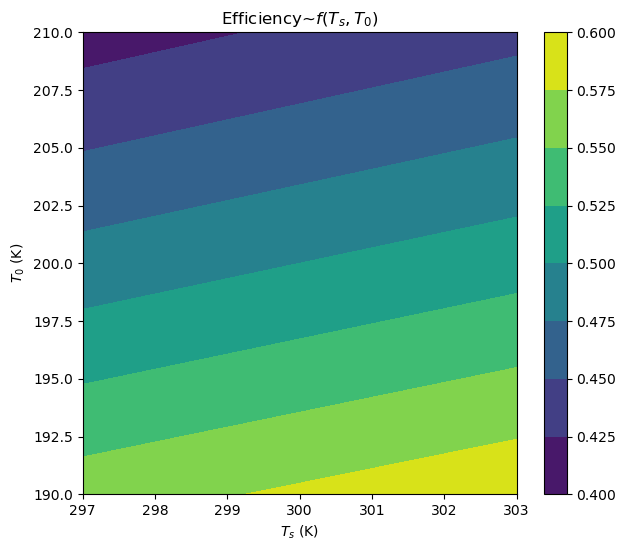

In [7]:
plt.figure(figsize=(7,6))
plt.contourf(Tsv,T0v,eta)
plt.xlabel('$T_s$ (K)')
plt.ylabel('$T_0$ (K)')
plt.colorbar()
plt.title('Efficiency~$f(T_s,T_0)$')
plt.show()

### Sensitivity of the term

In [8]:
300/200-1

0.5

In [9]:
250/200-1

0.25

In [10]:
300/(200+10)-1

0.4285714285714286

In [11]:
250/(200+10)-1

0.19047619047619047

At higher SSTs, the loss of efficiency as outflow temperature increases is higher than at cooler SSTs.

### Aside: sensitivity to the liquid-water heat capacity constant (`CL`)

The thermodynamics behind $T_0$ (and hence the efficiency term) depend on the entropy formulation in `tcpyPI.constants`, which uses **Emanuel's modified liquid-water specific heat, `CL = 2500` J/kg/K**, rather than the physical value (~4190 J/kg/K). This is deliberate: the modified value is internally consistent with the BE02/`pcmin.m` entropy expressions (and with the temperature dependence used in `tcpyPI.utilities.Lv`), and it keeps tcpyPI's outputs in agreement with the published MATLAB validation.

**How much does this choice matter?** Quantified on the ERA5 September-2024 North Atlantic sample (columns with $V_{max} > 40$ m/s): switching `CL` to the physical 4190 raises $V_{max}$ by **≈ +1.2 m/s (+1.8%) on average** (up to ≈ +5.5 m/s on marginal columns) and deepens $P_{min}$ by **≈ 5–6 hPa**, with only a small change in $T_0$ (≈ 0.05 K). In other words: a systematic but modest effect, well within the structural uncertainty of PI (e.g., the choice of $C_k/C_D$), and the `CL = 2500` convention is retained for BE02/pcmin consistency. See the `CL` entry in `src/tcpyPI/constants.py` for details (and the historical `checkCL` branch exploration).